<font size=10>**TASK 2 - SENTIMENT ANALYSIS**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How strong is the relationship between the polarity of a comments and its score?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Sentiment Analysis](#3)
    - [3.1 Specific Data Preparation](#3_1)
    - [3.2 Model Implementation](#3_2)
    - [3.3 Model Evaluation](#3_3)
- [4. Professors Implementation of Sentiment Analysis](#4)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [ ]:
import sys
import os

import pandas as pd

from scipy.stats import pearsonr

from nltk.tokenize import PunktSentenceTokenizer
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from sentiment_prep import *
from evaluation import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Sentiment Analysis**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

From the data exploration stage (Notebooks 01 and 02), several key insights emerged:

- The average value of the `overall` rating is **4.05**, which is very close to the maximum possible score of 5, indicating generally high customer satisfaction.  

- The majority of reviews in the `text` column are **short**, consisting of **1–2 sentences**. The `num_sentences` distribution supports this: median = 2, 75th percentile = 4, while the maximum reaches 43 sentences, suggesting a few exceptionally long reviews.

- Among the 20 most frequent tokens in the `atlanta_restaurants` dataset, **XX** and **XX** are the only terms that are *not* stopwords, highlighting the predominance of common words in customer reviews.

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation</font> <a class="anchor" id="3_1"></a>
  
[Back to TOC](#toc)

In [7]:
dataset["preproc_content"] =\
      dataset["text"].map(lambda content : main_pipeline(content,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ))

In [8]:
sent_tokenizer = PunktSentenceTokenizer()

dataset["preproc_sentences"] =\
      dataset["text"].map(lambda content : [main_pipeline(sentence,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ) for sentence in sent_tokenizer.tokenize(content)])

In [9]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].sample(1, random_state=42).values)
print("\nPreprocessed Content Sample:\n")
print(dataset[['preproc_content']].sample(1, random_state=42).values)
print("\nPreprocessed Sentences Sample:\n")
print(dataset[['preproc_sentences']].sample(1, random_state=42).values)

Original Text Sample:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Preprocessed Content Sample:

[['Wife & I visited The Red Eyed Mule . The food was good . The biscuits are soft, tasty and just right.The service was great . Atmosphere clean and positive . The decorations on wall is very educational . Overall, enjoyed my breakfast experience at Red Eyed Mule . We plan to return.']]

Preprocessed Sentences Sample:

[[list(['Wife & I visited The Red Eyed Mule.', 'The food was good.', 'The biscuits are soft, tasty and just right.The service was great.', 'Atmosphere clean and positive.', 'The decorations on wall is very educational.', 'Overall, enjoyed my breakfast experience at Red Eyed Mule.', 'We plan to return.'])]]


In sentiment analysis, we **skip feature extraction** and **vectorization** steps, from the *text mining fluxogram*, because the tools we use (VADER and TextBlob) work directly with raw text.

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="3_2"></a>
  
[Back to TOC](#toc)

### <font color='#BFD72F' size=6>3.2.1 VADER Sentiment Analysis</font> <a class="anchor" id="3_2_1"></a>
  
[Back to TOC](#toc)

#### **3.2.1.1 Compound Score of Entire Review** <a class="anchor" id="3_2_1_1"></a>
*Sentiment score computed from the full text of each review.*

In [10]:
vader_scores = dataset["preproc_content"].map(vader_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, vader_scores.add_prefix("content_polarity_vader_")], axis=1)

In [11]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print('\nVader Compound:\n', dataset[['content_polarity_vader_compound']].sample(1, random_state=42).values)
print('\nVader Positive:\n', dataset[['content_polarity_vader_pos']].sample(1, random_state=42).values)
print('\nVader Negative:\n', dataset[['content_polarity_vader_neg']].sample(1, random_state=42).values)
print('\nVader Neutral:\n', dataset[['content_polarity_vader_neu']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Vader Compound:
 [[0.9485]]

Vader Positive:
 [[0.257]]

Vader Negative:
 [[0.]]

Vader Neutral:
 [[0.743]]


<font size=5>**VADER Sentiment Analysis Interpretation**</font>

| Metric           | Value    | Description |
|------------------|----------|-------------|
| **Compound**     | 0.9485   | Indicates a strongly positive overall sentiment (range: -1 to +1) |
| **Positive**     | 0.257    | 25.7% of the text reflects positive sentiment |
| **Negative**     | 0.000    | No negative sentiment detected |
| **Neutral**      | 0.743    | 74.3% of the text is neutral or factual |


<font size=5>**Insights**</font>

- The **high compound score** confirms the review is overwhelmingly positive.
- The **positive sentiment** is driven by phrases like “food was good,” “biscuits are soft, tasty and just right,” and “service was great.”
- The **neutral score** is typical for descriptive reviews that include factual observations (e.g., atmosphere and wall decorations).
- The **absence of negative sentiment** reinforces the overall satisfaction expressed by the reviewer.


#### **3.2.1.2 Average Compound Score Across Sentences** <a class="anchor" id="3_2_1_2"></a>
*Mean sentiment score calculated from individual sentence-level analysis.*

In [12]:
mean_vader_scores = dataset["preproc_sentences"].map(vader_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, mean_vader_scores.add_prefix("mean_sentence_polarity_vader_")], axis=1)

In [13]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Sentence Vader Compound:\n", dataset[['mean_sentence_polarity_vader_compound']].sample(1, random_state=42).values)
print("\nAverage Sentence Vader Positive:\n", dataset[['mean_sentence_polarity_vader_pos']].sample(1, random_state=42).values)
print("\nAverage Sentence Vader Negative:\n", dataset[['mean_sentence_polarity_vader_neg']].sample(1, random_state=42).values)
print("\nAverage Sentence Vader Neutral:\n", dataset[['mean_sentence_polarity_vader_neu']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Sentence Vader Compound:
 [[0.33127143]]

Average Sentence Vader Positive:
 [[0.262]]

Average Sentence Vader Negative:
 [[0.]]

Average Sentence Vader Neutral:
 [[0.738]]


#### **3.2.1.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_1_3"></a>
*Scores Statistical comparison of both compound scoring approaches.*

In [14]:
pearson_r_vader, p_value_vader = pearsonr(dataset["content_polarity_vader_compound"],dataset["mean_sentence_polarity_vader_compound"])
print(f'Pearson correlation of content wise vader compound with mean sentences vader compound is: {pearson_r_vader}\nWhich means that, being so big, very few reviews have more than one sentence.')

Pearson correlation of content wise vader compound with mean sentences vader compound is: 0.8114668343234338
Which means that, being so big, very few reviews have more than one sentence.


### <font color='#BFD72F' size=6>3.2.2 TextBlob Sentiment Analysis</font> <a class="anchor" id="3_2_2"></a>
  
[Back to TOC](#toc)

#### **3.2.2.1 Polarity Score of Entire Review** <a class="anchor" id="3_2_2_1"></a>
*Sentiment polarity derived from the full review text.*

In [15]:
textblob_scores = dataset["preproc_content"].map(textblob_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, textblob_scores.add_prefix("content_polarity_textblob_")], axis=1)

In [16]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nTextblob Polarity:\n", dataset[['content_polarity_textblob_polarity']].sample(1, random_state=42).values)
print("\nTextblob Subjectivity:\n", dataset[['content_polarity_textblob_subjectivity']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Textblob Polarity:
 [[0.30189394]]

Textblob Subjectivity:
 [[0.39704545]]


<font size=5>**TextBlob Sentiment Analysis Interpretation**</font>

| Metric              | Value       | Description |
|---------------------|-------------|-------------|
| **Polarity**        | 0.3019      | Indicates a moderately positive sentiment (range: -1 to +1) |
| **Subjectivity**    | 0.3970      | Suggests a fairly objective tone (range: 0 to 1) |

<font size=5>**Insights**</font>
- The **positive polarity** reflects the reviewer’s satisfaction with the food, service, and atmosphere.
- The **moderate subjectivity** indicates that while the review contains personal opinions (e.g., “biscuits are soft, tasty and just right”), it also includes factual observations (e.g., “decorations on wall is very educational”).
- Overall, the review is **balanced**, leaning positive with a mix of descriptive and evaluative language.


#### **3.2.2.2 Average Polarity Across Sentences** <a class="anchor" id="3_2_2_2"></a>
*Mean polarity score based on sentence-level breakdown.*

In [17]:
mean_textblob_scores = dataset["preproc_sentences"].map(textblob_wrapper).apply(pd.Series)
dataset = pd.concat([dataset, mean_textblob_scores.add_prefix("mean_sentence_polarity_textblob_")], axis=1)

In [18]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Textblob Polarity Sample Across Sentences:\n", dataset[['mean_sentence_polarity_textblob_polarity']].sample(1, random_state=42).values)
print("\nAverage Textblob Subjectivity Sample Across Sentences:\n", dataset[['mean_sentence_polarity_textblob_subjectivity']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Textblob Polarity Sample Across Sentences:
 [[0.27694805]]

Average Textblob Subjectivity Sample Across Sentences:
 [[0.33300866]]


#### **3.2.2.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_2_3"></a>
*Polarity Evaluating consistency between aggregate and granular polarity scores.*

In [19]:
pearson_r_textblob, p_value_textblob = pearsonr(dataset["content_polarity_textblob_polarity"],dataset["mean_sentence_polarity_textblob_polarity"])
print(f'Pearson correlation of content wise textblob polarity with mean sentences textblob polarity is: {pearson_r_vader}\nWhich means that, being so big, very few reviews have more than one sentence')

Pearson correlation of content wise textblob polarity with mean sentences textblob polarity is: 0.8114668343234338
Which means that, being so big, very few reviews have more than one sentence


## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="3_3"></a>
  
[Back to TOC](#toc)

*VADER vs TextBlob: Performance Evaluation Using RMSE and MAPE*

In [63]:
# Initialize scaler to scale values between 1 and 5
scaler = MinMaxScaler(feature_range=(1, 5))

# Normalize stars
normalized_score = scaler.fit_transform(dataset["stars"].to_numpy().reshape(-1, 1))
dataset["stars_scaled"] = normalized_score

In [64]:
# Define groups of columns to scale
vader_columns = [

    "content_polarity_vader_compound",
    "content_polarity_vader_pos",
    "content_polarity_vader_neg",
    "content_polarity_vader_neu",

    "mean_sentence_polarity_vader_compound",
    "mean_sentence_polarity_vader_pos",
    "mean_sentence_polarity_vader_neg",
    "mean_sentence_polarity_vader_neu"
    
]

# Loop over columns and scale them
for col in vader_columns:
    scaled_col_name = f"{col}_scaled"
    dataset[scaled_col_name] = scaler.fit_transform(dataset[col].to_numpy().reshape(-1, 1))

In [104]:
# --- Subset comparisons (positive/negative/neutral reviews) ---
pos_reviews = dataset[dataset["stars"] > 3.0]
neg_reviews = dataset[dataset["stars"] < 3.0]
neu_reviews = dataset[dataset["stars"] == 3.0]

# Positive reviews
well_classified_pos_pct = (pos_reviews['content_polarity_vader_pos_scaled'] > 3.5).sum() / len(pos_reviews) * 100
print(f"Well Classified Positive Reviews: {well_classified_pos_pct:.2f}%")

# Negative reviews
well_classified_neg_pct = (neg_reviews['content_polarity_vader_neg_scaled'] < 2.5).sum() / len(neg_reviews) * 100
print(f"Well Classified Negative Reviews: {well_classified_neg_pct:.2f}%")

# Neutral reviews
mask = (neu_reviews['content_polarity_vader_neu_scaled'] >= 2.5) & \
       (neu_reviews['content_polarity_vader_neu_scaled'] <= 3.5)
well_classified_neutral_pct = (mask.sum() / len(neu_reviews)) * 100

print(f"Well Classified Neutral Reviews: {well_classified_neutral_pct:.2f}%")

Well Classified Positive Reviews: 14.22%
Well Classified Negative Reviews: 95.20%
Well Classified Neutral Reviews: 10.61%


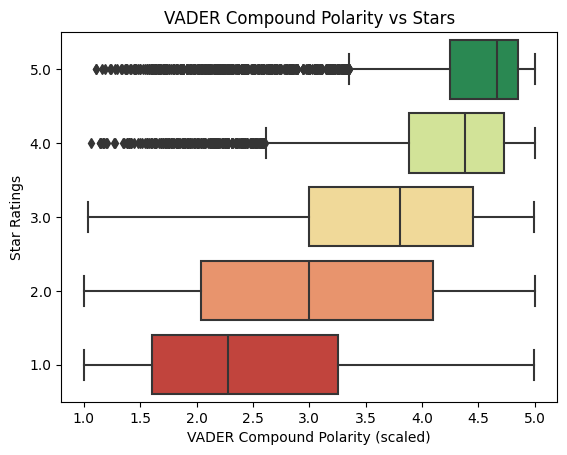

In [105]:

# Convert stars to categorical (for boxplot)
dataset["stars_cat"] = dataset["stars"].astype(str)

# Map each star rating to a color from the RATINGS_PALLETE
star_order = ["5.0", "4.0", "3.0", "2.0", "1.0"]
inverted_palette = list(reversed(ColorPalette.RATINGS_PALLETE))
palette_colors = dict(zip(star_order, inverted_palette))

# Plot boxplot
sns.boxplot(
    data=dataset,
    x="content_polarity_vader_compound_scaled",
    y="stars_cat",
    order=star_order,
    palette=palette_colors
)

plt.xlabel("VADER Compound Polarity (scaled)")
plt.ylabel("Star Ratings")
plt.title("VADER Compound Polarity vs Stars")
plt.show()

In [106]:
# Select columns for correlation
corr_cols = [
    "stars_scaled",
    "content_polarity_vader_compound_scaled",
    "content_polarity_vader_pos_scaled",
    "content_polarity_vader_neg_scaled",
    "content_polarity_vader_neu_scaled",
    "mean_sentence_polarity_vader_compound_scaled",
    "content_polarity_textblob_polarity_scaled",
    "mean_sentence_polarity_textblob_polarity_scaled"
]

# Compute correlation matrix
corr_matrix = dataset[corr_cols].corr()

# Convert correlation matrix to long format for Plotly
corr_long = corr_matrix.reset_index().melt(id_vars="index")
corr_long.columns = ["Feature1", "Feature2", "Correlation"]

# Interactive heatmap with Plotly
fig = px.imshow(
    corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    color_continuous_scale="RdBu_r",  # blue = negative, red = positive
    text_auto=".2f",
    aspect="auto"
)

fig.update_layout(
    title="Correlation Matrix: Sentiment Features vs Star Ratings",
    xaxis_title="Features",
    yaxis_title="Features",
    width=800,
    height=800
)

fig.show()


In [67]:
# List of TextBlob columns to scale
textblob_columns = [

    "content_polarity_textblob_polarity",
    "content_polarity_textblob_subjectivity",

    "mean_sentence_polarity_textblob_polarity",
    "mean_sentence_polarity_textblob_subjectivity"
    
]

# Scale each column to range 1-5
for col in textblob_columns:
    scaled_col_name = f"{col}_scaled"
    dataset[scaled_col_name] = scaler.fit_transform(dataset[col].to_numpy().reshape(-1, 1))

In [74]:
# Define comparisons using scaled columns
comparisons = {
    "VADER VS Stars": ("content_polarity_vader_compound_scaled", "stars_scaled"),
    "VADER (mean sentences) VS Stars": ("mean_sentence_polarity_vader_compound_scaled", "stars_scaled"),
    "TextBlob VS Stars": ("content_polarity_textblob_polarity_scaled", "stars_scaled"),
    "TextBlob (mean sentences) VS Stars": ("mean_sentence_polarity_textblob_polarity_scaled", "stars_scaled"),
    "VADER vs TextBlob": ("content_polarity_vader_compound_scaled", "content_polarity_textblob_polarity_scaled")
}

metrics = {}

# Compute metrics using compute_metrics()
for name, (pred_col, true_col) in comparisons.items():
    y_pred = dataset[pred_col]
    y_true = dataset[true_col]

    metrics[name] = compute_metrics(y_true, y_pred)

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df

,VADER VS Stars,VADER (mean sentences) VS Stars,TextBlob VS Stars,TextBlob (mean sentences) VS Stars,VADER vs TextBlob
Pearson R,0.677,0.671,0.634,0.614,0.634
RMSE,1.067,1.176,1.182,1.227,0.854
MAPE,0.213,0.261,0.258,0.270,0.159


Pearson R between VADER and TextBlob: 0.634


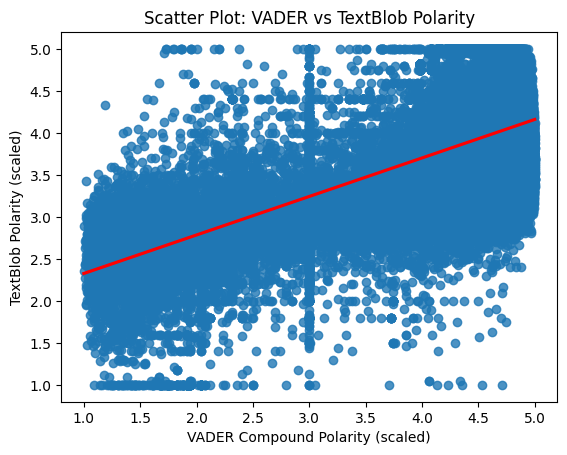

In [ ]:
# Compute Pearson correlation between VADER and TextBlob scaled polarity
pearson_r, p_value = pearsonr(
    dataset["content_polarity_vader_compound_scaled"],
    dataset["content_polarity_textblob_polarity_scaled"]
)
print(f"Pearson R between VADER and TextBlob: {pearson_r:.3f}")

# Scatter plot with regression line
sns.regplot(
    data=dataset,
    x="content_polarity_vader_compound_scaled",
    y="content_polarity_textblob_polarity_scaled",
    line_kws={"color": "red"}
)
plt.xlabel("VADER Compound Polarity (scaled)")
plt.ylabel("TextBlob Polarity (scaled)")
plt.title("Scatter Plot: VADER vs TextBlob Polarity")
plt.show()

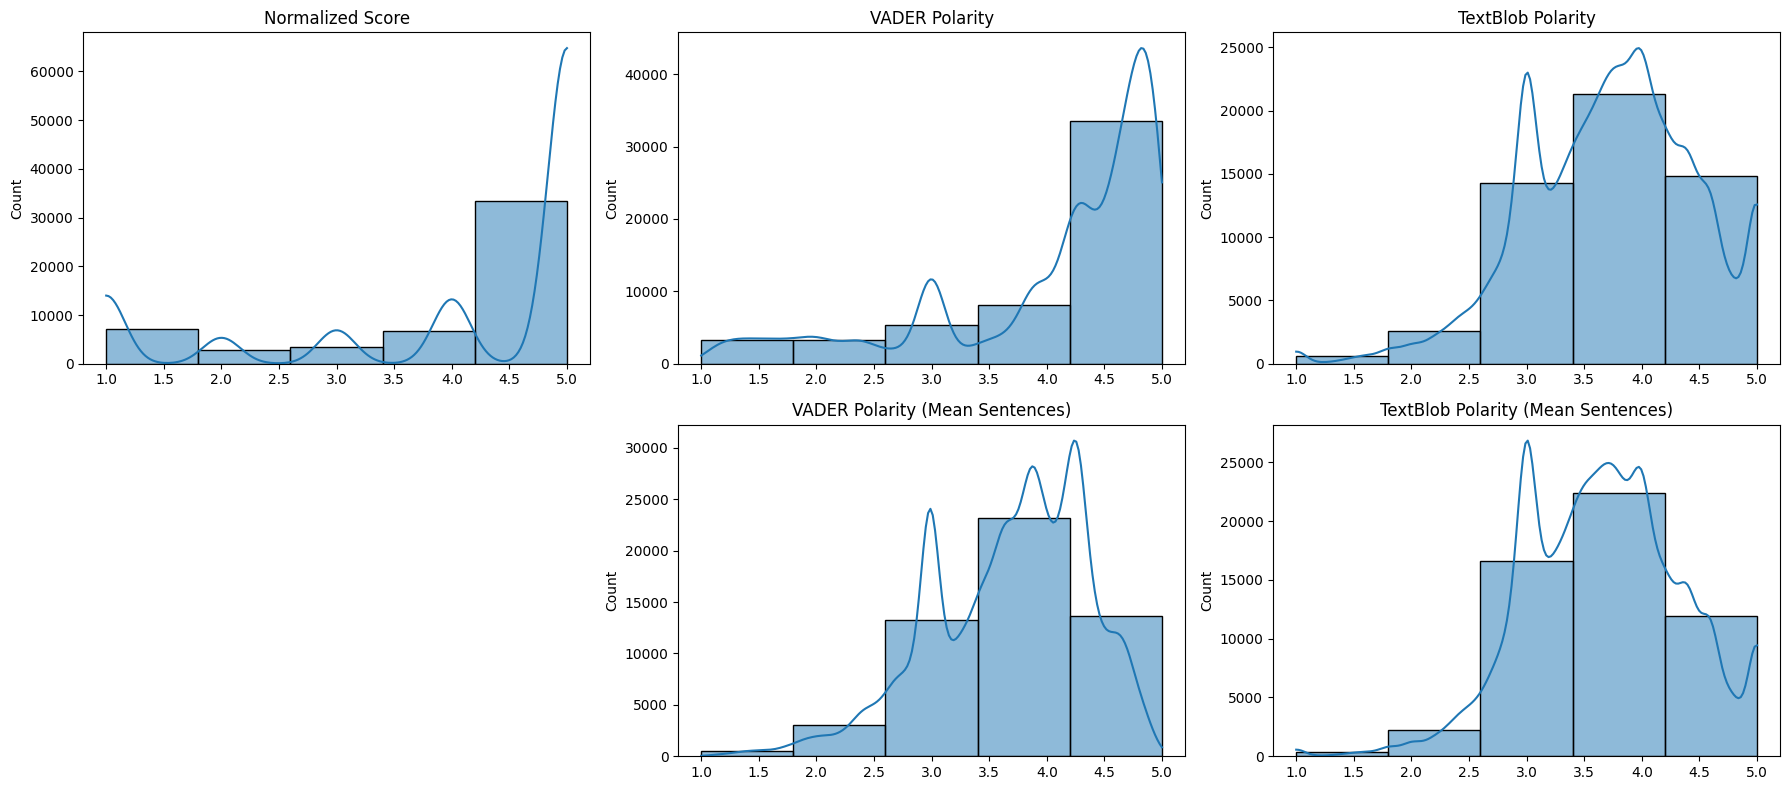

In [75]:
# Define columns and titles
cols_titles = [
    ("stars_scaled", "Normalized Score"),
    ("content_polarity_vader_compound_scaled", "VADER Polarity"),
    ("content_polarity_textblob_polarity_scaled", "TextBlob Polarity"),
    ("mean_sentence_polarity_vader_compound_scaled", "VADER Polarity (Mean Sentences)"),
    ("mean_sentence_polarity_textblob_polarity_scaled", "TextBlob Polarity (Mean Sentences)")
]

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()  # flatten to 1D, always safe

# Index of the subplot to leave empty (bottom-left in 2x3 grid)
empty_index = 3

# Prepare axes to plot (skip the empty one)
axes_to_use = [ax for i, ax in enumerate(axes) if i != empty_index]

# Plot the histograms
for ax, (col, title) in zip(axes_to_use, cols_titles):
    sns.histplot(dataset[col], kde=True, bins=5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Turn off the empty subplot
axes[empty_index].axis("off")

plt.tight_layout()
plt.show()

## <font color='#BFD72F' size=6>3.4 Answer the Question</font> <a class="anchor" id="3_4"></a>
  
[Back to TOC](#toc)

**How strong is the relationship between the polarity of a comments and its score?**

*(Sentiment Analysis with Correlation Matrix)*

Based on our analysis, **Vader** shows a slightly stronger correlation with review scores compared to TextBlob. 

Therefore, we focus on the correlation between the Vader polarity when applied to the **entire review** (rather than individual sentences) and its corresponding star rating, which makes sense as the majority of reviews have 1 or 2 sentences  

- **Pearson correlation (R):** 0.677  
- **RMSE:** 1.067  
- **MAPE:** 0.213

While the correlation is moderate—not exceptionally strong—it still reflects a **clear trend**:  
> More positive comments tend to receive higher star ratings.

The distribution plots support this observation. VADER polarity scores, when applied to full reviews, show a consistent alignment with normalized star ratings. This suggests that>
> VADER effectively captures the overall sentiment direction, even if it doesn't account for all the variability in user ratings.

In summary, VADER offers a reliable signal for sentiment analysis in short-form reviews, making it a suitable choice for predicting user satisfaction.

However, for more nuanced or longer-form reviews, combining VADER with other models or features (e.g., review length, subjectivity, or topic modeling) may yield better predictive performance.